In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [13]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63284 entries, 0 to 63283
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      63283 non-null  float64
 1   miktar                      51466 non-null  float64
 2   markalar                    61110 non-null  object 
 3   etiketler                   44298 non-null  object 
 4   alerjenler                  63284 non-null  object 
 5   eser_miktarlar              63284 non-null  object 
 6   icerik_sayisi               55428 non-null  float64
 7   nutriscore_notu             63225 non-null  object 
 8   nova_grubu                  54184 non-null  float64
 9   yesil_skor_notu             47023 non-null  object 
 10  palmiye_yagi_icermez        51736 non-null  object 
 11  vejetaryen                  49282 non-null  object 
 12  vegan_durumu                55745 non-null  object 
 13  enerji_kcal                 626

In [15]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,6.328300e+04,5.146600e+04,55428.000000,54184.000000,62672.000000,62668.000000,62012.000000,62617.000000,62381.000000,44740.000000,62664.000000,62794.000000,3133.000000,17662.000000
mean,6.047567e+12,1.348576e+08,13.013315,3.097243,270.736725,14.260466,4.749099,26.745052,10.215321,3.247396,7.534038,6.883827,5.022180,13.875490
std,4.055795e+14,2.655425e+10,13.442290,1.155425,384.275435,33.634889,8.662934,29.458370,20.865034,4.995045,9.331768,1420.676878,19.926298,30.946291
min,1.526000e+03,0.000000e+00,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,-0.179539,0.000000,-0.450000
25%,3.256226e+12,5.000000e+01,4.000000,3.000000,76.000000,1.000000,0.200000,4.000000,0.500000,0.400000,1.600000,0.030000,0.000000,0.000000
50%,4.011801e+12,2.000000e+02,10.000000,4.000000,234.000000,5.300000,1.300000,12.800000,3.200000,1.900000,5.900000,0.300000,0.000000,0.000000
75%,5.942328e+12,4.000000e+02,18.000000,4.000000,411.000000,20.800000,5.800000,52.600000,10.909091,4.400000,10.000000,0.982500,0.000000,7.400000
max,1.020304e+17,5.940568e+12,405.000000,4.000000,49328.000000,5856.650000,450.000000,1900.000000,1700.000000,375.000000,800.000000,355942.500000,100.000000,449.400000


In [16]:
data.sample(5)

,barkod,miktar,markalar,etiketler,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
23765,3.261056e+12,1200.00,william saurin,No preservatives,"['Gluten', 'Milk', 'Soybeans']","['Gluten', 'Milk', 'Soybeans']",44.0,B,4.0,A,NaN,False,no,114.0,4.70,1.85,8.90,0.60,NaN,7.3,0.80,NaN,NaN,g,"['Meats and their products', 'Meals', 'Meals w...",['No preservatives']
9214,3.596710e+12,0.16,auchan,"Fed without GMOs, ,, No GMOs, ,, In braille, ,...",['Fish'],[],3.0,A,3.0,D,True,False,no,75.0,4.20,0.60,0.50,0.50,0.5,9.1,1.20,NaN,NaN,kg,"['Seafood', 'Fishes and their products', 'Fish...","['Fed without GMOs', 'No GMOs', 'In braille', ..."
44494,5.601010e+12,125.00,pingo doce,"Green Dot, ,, pt:Ecoponto-amarelo","['Gluten', 'Milk']",[],30.0,D,4.0,C,False,True,yes,468.0,23.00,11.00,57.00,1.30,9.0,7.5,0.60,NaN,NaN,g,"['Snacks', 'Sweet snacks', 'Biscuits and cakes...","['Green Dot', 'pt:Ecoponto-amarelo']"
1852,6.111250e+12,3.00,oceanos,Green Dot,['Fish'],[],8.0,A,4.0,D,NaN,False,no,130.0,5.93,0.83,4.33,3.33,1.0,14.6,1.20,0.0,NaN,x,"['Seafood', 'Fishes and their products', 'Cann...",['Green Dot']
60130,5.060972e+12,173.00,gü,"Sustainable, ,, Sustainable Palm Oil, ,, Certi...","['Eggs', 'Gluten', 'Milk', 'Nuts', 'Soybeans']",[],48.0,E,4.0,B,False,False,no,414.0,25.00,14.00,43.00,31.00,0.9,3.9,0.41,NaN,0.0,g,"['Snacks', 'Sweet snacks', 'Biscuits and cakes...","['Sustainable', 'Sustainable Palm Oil', 'Certi..."


In [17]:
data.isnull().mean() * 100

barkod                         0.001580
miktar                        18.674546
markalar                       3.435308
etiketler                     30.001264
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                 12.413880
nutriscore_notu                0.093231
nova_grubu                    14.379622
yesil_skor_notu               25.695278
palmiye_yagi_icermez          18.247898
vejetaryen                    22.125656
vegan_durumu                  11.912964
enerji_kcal                    0.967069
yag_g                          0.973390
doymus_yag_g                   2.009987
karbonhidrat_g                 1.053979
seker_g                        1.426901
lif_g                         29.302825
protein_g                      0.979711
tuz_g                          0.774287
alkol_yuzde                   95.049302
meyve_sebze_baklagil_yuzde    72.090892
birim                         20.629227
kategori_listesi               0.000000


In [18]:
for column in data.columns:
    unique_values = data[column].astype(str).unique()
    unique_values_str = sorted(list(unique_values))
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")

barkod (63092): ['1.020304050607081e+17', '1000029852900.0', '10001219.0', '10001295.0', '10001356.0', '10001400.0', '10001404.0', '10001691.0', '10001707.0', '10001875.0'] ...
miktar (1133): ['0.0', '0.03', '0.042', '0.045', '0.046', '0.05', '0.055', '0.06', '0.065', '0.07'] ...
markalar (12268): ['"tradition culinaire"', "'z bregov", '(sans marque)', '07x netto 03.25', '1 2 3 fruits', '1 attimo in forma', '1 l', '1 x auer 01.25', '1%', '1-2-3'] ...
etiketler (18879): ['1', '1 of 5 a day', '1% for the planet', '1% for the planet, ,, Triman', '10 Percent Coconut Water BCAA 700mg Eleytrocltyes Antioxidant B Vits', '100% Milch aus Österreich', '100% arabica', '100% arabica, ,, Triman', '100% arabica, ,, pt:Certificado Gourmet ABIC', '100% italian'] ...
alerjenler (1800): ["['Acesulfame-potassium']", "['Apple', 'Banana', 'Celery', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Nuts']", "['Apple', 'Banana', 'Gluten', 'Sulphur 

In [19]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Nuts                                                 8912
Soybeans                                             6836
Milk                                                 5620
Gluten                                               4371
Eggs                                                 3907
Sesame seeds                                         3867
Mustard                                              3418
Peanuts                                              2521
Celery                                               2190
Fish                                                 1195
Crustaceans                                          1045
Molluscs                                              890
Lupin                                                 720
Sulphur dioxide and sulphites                         509
Cereals-with-gluten                                    28
Crustaceans-and-shellfish                              26
En-nuts                  

In [ ]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['etiketler_listesi']:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 500 ---")
    print(counts.head(500))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- etiketler_listesi - Top 50 ---
etiketler_listesi
Nutriscore                                              12622
Organic                                                  9702
Green Dot                                                8835
Vegetarian                                               8395
EU Organic                                               8212
No gluten                                                6379
Vegan                                                    6322
AB Agriculture Biologique                                4826
Nutriscore Grade A                                       4628
Triman                                                   4489
No preservatives                                         3524
Made in France                                           3445
EU Agriculture                                           2948
FR-BIO-01                                                2697
No added sugar                                           2574
Non-EU Agricultur

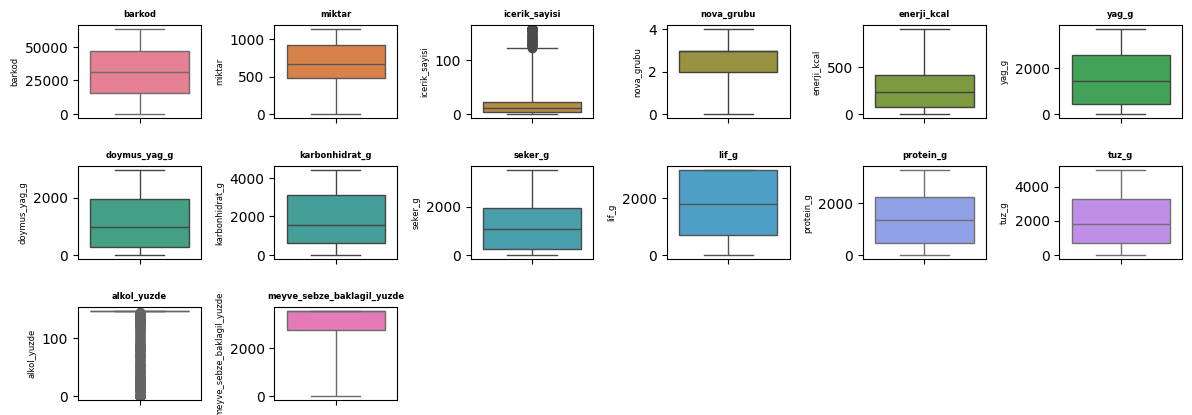

In [21]:
from sklearn.calibration import LabelEncoder
import seaborn as sns

veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

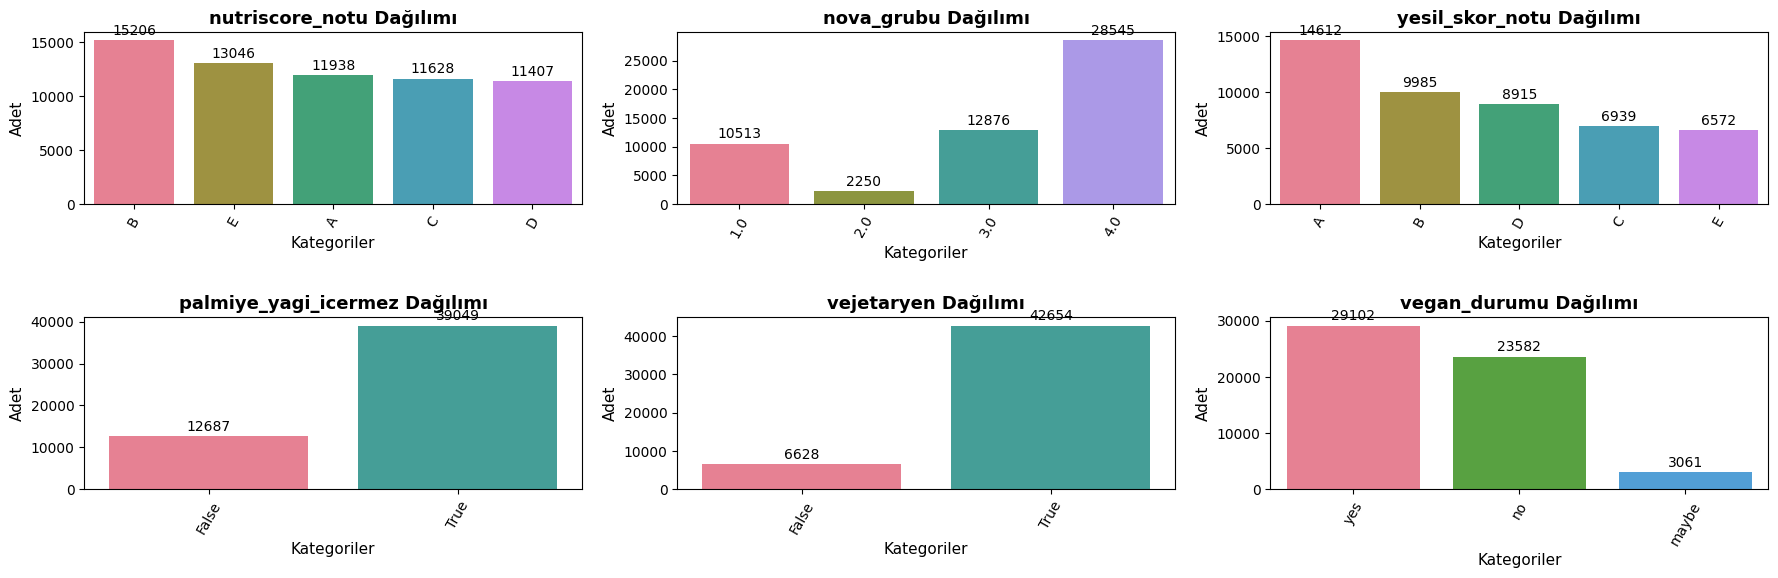

In [22]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    val_counts = data[column].value_counts()
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Kategoriler", fontsize=11)
    axes[i].set_ylabel("Adet", fontsize=11)
    axes[i].tick_params(axis='x', rotation=60)

    # Her sütunun üzerine değerleri ekleyelim
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                         textcoords='offset points')

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
plt.show()
